Ejemplo de clasificación sobre el **iris dataset** usando máquinas de vectores soporte - support vector machines (SVM).

In [1]:
import numpy as np
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC # SVC: Support Vector Classification

In [2]:
iris = datasets.load_iris()
X = iris["data"][:, (2, 3)] # We will use two predictor attributes: petal length, petal width
y = (iris["target"] == 2). astype(np.float64) # Reformulate the problem as binary classification: virginica VS not virginica

svm_classifier = Pipeline([
                           ("scaler", StandardScaler()),
                           ("linear_svc", LinearSVC(C=1, loss="hinge")),
])

svm_classifier.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('linear_svc', LinearSVC(C=1, loss='hinge'))])

In [3]:
svm_classifier.predict([[5.5, 1.7], [4.7, 1.6]])

array([1., 0.])

**EJERCICIOS PROPUESTOS**

* Separar los datos del dataset *iris* en datos de entrenamiento y de prueba.
* Entrenar varios modelos SVM con diferentes configuraciones para **C**.
* Evaluar los modelos entrenados en el conjunto de prueba (y también en los propios datos de entrenamiento), comparar e interpretar los resultados obtenidos.

In [4]:
svm_classifier = Pipeline([
                           ("scaler", StandardScaler()),
                           ("linear_svc", LinearSVC(C=1, loss="hinge")),
])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, )

svm_classifier.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('linear_svc', LinearSVC(C=1, loss='hinge'))])

In [5]:
# Helper code to evaluate classification models (remove comments '#' before use):
from sklearn.metrics import accuracy_score

y_test_pred = svm_classifier.predict(X_test)
accuracy_score(y_test, y_test_pred)

0.9333333333333333

**UN PASO MÁS ALLÁ: SVMs no lineales** (*kernel polinomial*)

Estos tipos avanzados de SVMs son más adecuados para clasificar datos que no son linealmente separables. Mediante complejas operaciones matemáticas, los datos se transforman y proyectan en un espacio dimensional diferente (generalmente mayor) para que sean linealmente separables.

Las SVMs capaces de realizar esta clasificación se denominan **Kernel SVMs** y pueden implementar diferentes tipos de funciones kernel, como:

* **Polinomia**: (*kernel = "poly"*) los límites de decisión aprendidos se asemejan a una curva polinomial de grado especificado por nosotros.
* **Gaussiana**: (*kernel = "rbf"*) adecuada para separar datos que se presupone que siguen una distribución gaussiana. 'RBF' significa *función de base radial*.





In [6]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

from sklearn.svm import SVC

poly_kernel_svm_clf = Pipeline([
        ("scaler", StandardScaler()),
        ("svm_clf", SVC(kernel="poly", degree=3, coef0=1, C=5))
    ])
poly_kernel_svm_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm_clf', SVC(C=5, coef0=1, kernel='poly'))])

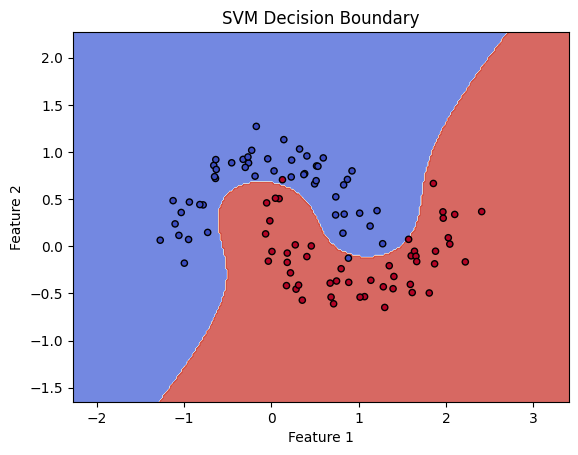

Decision boundary plot generated successfully.


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_predictions(clf, X, y):
    # Helper function to plot the dataset and the decision boundary for an SVM classifier
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('SVM Decision Boundary')
    plt.show()

plot_predictions(poly_kernel_svm_clf, X, y)
print("Decision boundary plot generated successfully.")